In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast


In [ ]:
df = pd.read_csv('details_anime_movies_2000.csv')

# converting string of a list into literal list
df['genres'] = df['genres'].apply(ast.literal_eval)
df['production_studios'] = df['production_studios'].apply(ast.literal_eval)

# filtering out the genre animation, due to all movies being animation movies
df['genres'] = df['genres'].apply(lambda g: [x for x in g if x != "Animation" and    x != "TV Movie"])

# breaking up genre combinations, to get single categories
genres = df['genres'].explode()

# assigning values to each genre to quantify them
genre_dummies = pd.get_dummies(genres)
genre_dummies = genre_dummies.groupby(level=0).sum()

df = pd.concat([df, genre_dummies], axis=1)

# breaking up production companies to get single categories
studios = df['production_studios'].explode()

# only showing the 10 most often shown movies
top_studios = studios.value_counts().head(10).index


for studio in top_studios:
    df[studio] = df["production_studios"].apply(lambda x: int(studio in x))

y = df['avg_score']

X = df[
    ["runtime", "release_year"] +
    list(genre_dummies.columns) +
    list(top_studios)
]
X = np.array(X)
y = np.array(y)

X = np.c_[np.ones(X.shape[0]), X] # add intercept

beta = np.linalg.lstsq(X, y, rcond=None)[0]

features = ['intercept', 'runtime', 'release_year'] + list(genre_dummies.columns) + list(top_studios)

coeff_df = pd.DataFrame({
    'feature' : features,
    'coefficient' : beta
})


print(coeff_df.sort_values('coefficient',ascending=False))


print(df.head())
print(df.info())

                                  feature  coefficient
26                               Shueisha     0.417090
20                                 dentsu     0.267773
12                                  Music     0.239695
7                                   Drama     0.206474
13                                Mystery     0.185232
25                         Toei Animation     0.143222
5                                  Comedy     0.133332
27                               KADOKAWA     0.108092
14                                Romance     0.069771
18                                   TOHO     0.037465
2                            release_year     0.005147
1                                 runtime     0.004186
9                                 Fantasy    -0.000964
4                               Adventure    -0.029130
24        Shogakukan-Shueisha Productions    -0.036176
19                                Aniplex    -0.046497
16                               Thriller    -0.046918
8         

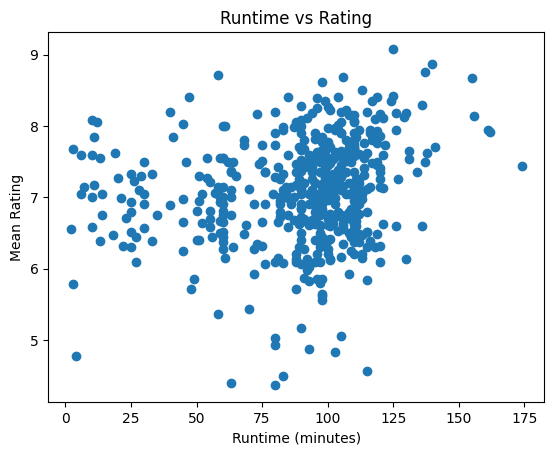

In [9]:
plt.scatter(df['runtime'], df['avg_score'])
plt.xlabel("Runtime (minutes)")
plt.ylabel("Mean Rating")
plt.title("Runtime vs Rating")
plt.show()

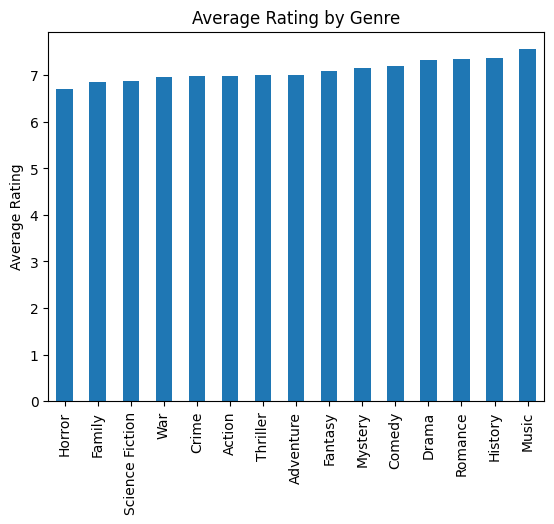

In [6]:
genre_means = {}

for g in genre_dummies.columns:
    genre_means[g] = df[df[g] == 1]['avg_score'].mean()

pd.Series(genre_means).sort_values().plot(kind='bar')

plt.ylabel("Average Rating")
plt.title("Average Rating by Genre")
plt.show()

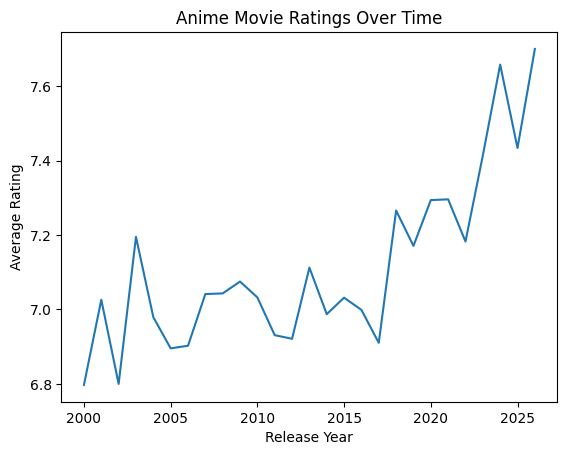

In [7]:
year_means = df.groupby('release_year')["avg_score"].mean()

year_means.plot()

plt.xlabel("Release Year")
plt.ylabel("Average Rating")
plt.title("Anime Movie Ratings Over Time")
plt.show()

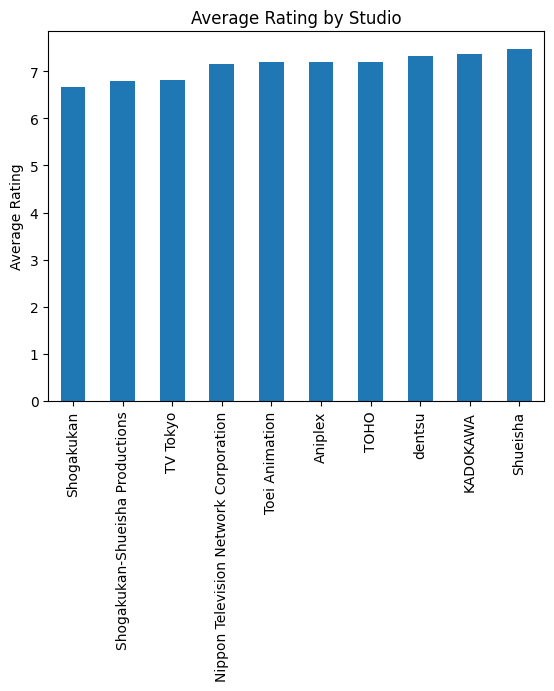

In [8]:
studio_scores = {}

for s in top_studios:
    studio_scores[s] = df[df[s] == 1]['avg_score'].mean()

pd.Series(studio_scores).sort_values().plot(kind="bar")

plt.ylabel("Average Rating")
plt.title("Average Rating by Studio")
plt.show()